# Unsupervised Learning – PCA and Clustering of US Arrests (1973)

This notebook performs an in-depth analysis of the USArrests dataset, which records arrests per 100,000 residents for Murder, Assault and Rape across all 50 US states in 1973, along with the percentage of the population living in urban areas (UrbanPop).

The analysis covers data exploration and preprocessing, a correlation analysis, Principal Component Analysis (PCA) with a biplot, selection of the optimal number of principal components and K-Means and Hierarchical clustering on the PCA-reduced data.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 7)
sns.set_style('whitegrid')

## 1. Data Exploration

I begin by loading the dataset and examining its structure, data types, summary statistics and any missing values. This informs the preprocessing decisions I make in the next section.

In [2]:
# ── Load dataset ────────────────────────────────────────────────────────────
df = pd.read_csv('UsArrests.csv')

# Ensure state names are used as index when provided in a City column
if 'City' in df.columns:
    df = df.set_index('City')

# Keep only numeric features for analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) != df.shape[1]:
    dropped = [c for c in df.columns if c not in numeric_cols]
    print(f"Dropping non-numeric columns: {dropped}")
df = df[numeric_cols].copy()

# ── Basic structure ──────────────────────────────────────────────────────────
print(f"Shape: {df.shape}  ({df.shape[0]} states, {df.shape[1]} numeric features)\n")
print("First 10 rows:")
display(df.head(10))

print("\nData types:")
print(df.dtypes)

print("\nDescriptive statistics:")
display(df.describe().round(2))

print("\nMissing values per column:")
print(df.isnull().sum())

Shape: (50, 4)  (50 states, 4 numeric features)

First 10 rows:


,Murder,Assault,UrbanPop,Rape
City,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9



Data types:
Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
dtype: object

Descriptive statistics:


,Murder,Assault,UrbanPop,Rape
count,50.00,50.00,50.00,50.00
mean,7.79,170.76,65.54,21.23
std,4.36,83.34,14.47,9.37
min,0.80,45.00,32.00,7.30
25%,4.08,109.00,54.50,15.08
50%,7.25,159.00,66.00,20.10
75%,11.25,249.00,77.75,26.18
max,17.40,337.00,91.00,46.00



Missing values per column:
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64


## 2. Preprocessing

**Motivation for standardisation:**  
The four features are measured on very different scales — Assault values range up to ~337 arrests per 100,000, while Murder values rarely exceed 18. If I fed the raw values into PCA, the algorithm would be dominated by the feature with the largest variance (Assault), not because it is more informative, but simply because its numbers are larger.

By applying zero-mean, unit-variance standardisation (StandardScaler) I ensure each feature contributes equally to the PCA. This is standard practice whenever the features have different units or magnitudes.

I also inspect boxplots to check for extreme outliers that might distort the analysis.

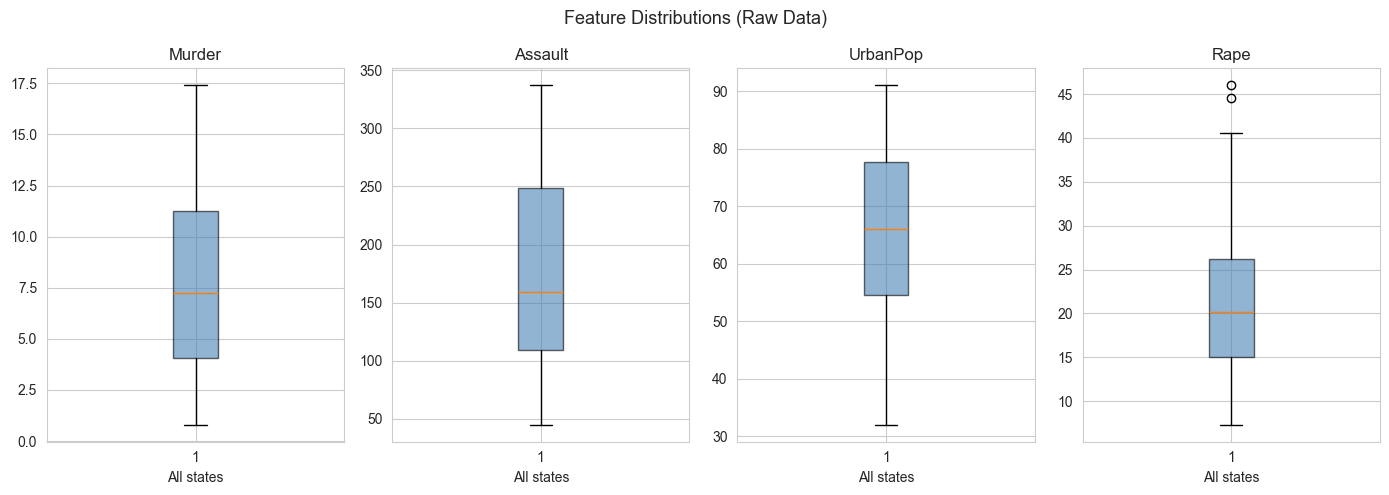

Post-scaling statistics (mean ≈ 0, std ≈ 1):


,Murder,Assault,UrbanPop,Rape
count,50.000,50.000,50.000,50.000
mean,-0.000,0.000,-0.000,0.000
std,1.010,1.010,1.010,1.010
min,-1.621,-1.524,-2.341,-1.503
25%,-0.861,-0.749,-0.770,-0.664
50%,-0.125,-0.143,0.032,-0.122
75%,0.803,0.948,0.852,0.533
max,2.229,2.015,1.777,2.671


In [3]:
# ── Boxplots before scaling ─────────────────────────────────────────────────
n_features = len(df.columns)
fig, axes = plt.subplots(1, n_features, figsize=(3.5 * n_features, 5))
if n_features == 1:
    axes = [axes]

for ax, col in zip(axes, df.columns):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
    ax.set_xlabel('All states')
fig.suptitle('Feature Distributions (Raw Data)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Standardise ──────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(X_scaled, index=df.index, columns=df.columns)

print("Post-scaling statistics (mean ≈ 0, std ≈ 1):")
display(df_scaled.describe().round(3))

## 3. Correlation Analysis

A Pearson correlation matrix reveals the linear relationships among the four features before I reduce dimensionality. Strong correlations indicate that some variables share underlying variance, which PCA is designed to capture efficiently.

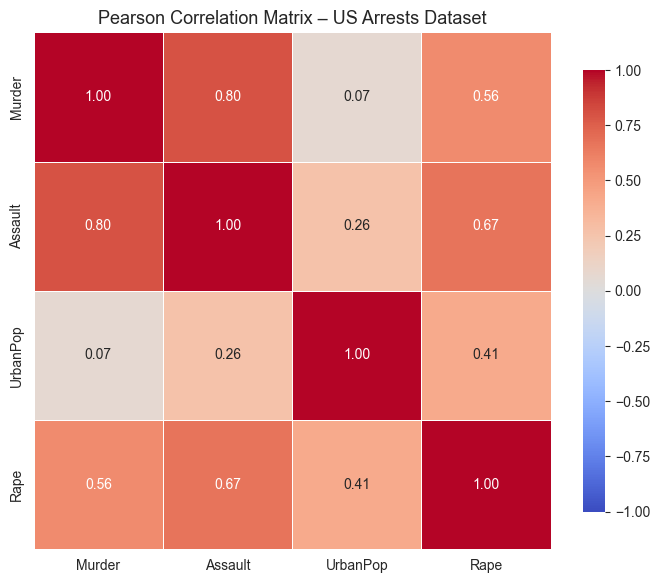

Correlation matrix (rounded):


,Murder,Assault,UrbanPop,Rape
Murder,1.000,0.802,0.070,0.564
Assault,0.802,1.000,0.259,0.665
UrbanPop,0.070,0.259,1.000,0.411
Rape,0.564,0.665,0.411,1.000


In [4]:
corr = df.corr()

plt.figure(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # upper-triangle mask (keep lower)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Pearson Correlation Matrix – US Arrests Dataset', fontsize=13)
plt.tight_layout()
plt.show()

print("Correlation matrix (rounded):")
display(corr.round(3))

### Interpretation

Murder and Assault show a strong positive correlation (r ≈ 0.80), indicating that states with high murder rates also tend to have high assault rates — suggesting a shared underlying factor of overall violent-crime intensity. Murder and Rape are moderately correlated (r ≈ 0.56), as are Assault and Rape (r ≈ 0.67). UrbanPop shows much weaker correlations with the crime variables (r ≈ 0.07–0.41), indicating that urbanisation is a partially independent dimension. The strongest link between urbanisation and crime is with Rape (r ≈ 0.41), which may reflect higher reporting rates in cities.

Overall, three of the four variables — Murder, Assault and Rape — share substantial variance, suggesting one dominant principal component capturing *overall crime level*, while UrbanPop is more orthogonal and is likely to dominate a second component.

## 4. Principal Component Analysis (PCA)

PCA is applied to the standardised data. Each principal component (PC) is a linear combination of the original features that captures a decreasing share of the total variance. I inspect the **loadings** (eigenvectors) to understand what each PC represents.

In [5]:
pca_full = PCA()
pca_full.fit(X_scaled)

scores_full  = pca_full.transform(X_scaled)
expl_var     = pca_full.explained_variance_ratio_
cumul_var    = np.cumsum(expl_var)
eigenvalues  = pca_full.explained_variance_   # = variance of each PC

# ── Loadings table ───────────────────────────────────────────────────────────
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=df.columns,
    columns=[f'PC{i+1}' for i in range(len(expl_var))]
)
print("PCA Loadings (contribution of each feature to each PC):")
display(loadings.round(4))

# ── Variance table ───────────────────────────────────────────────────────────
var_table = pd.DataFrame({
    'Eigenvalue':          eigenvalues.round(4),
    'Explained Variance':  (expl_var * 100).round(2),
    'Cumulative Variance': (cumul_var * 100).round(2)
}, index=[f'PC{i+1}' for i in range(len(expl_var))])
print("\nVariance explained per principal component:")
display(var_table)

PCA Loadings (contribution of each feature to each PC):


,PC1,PC2,PC3,PC4
Murder,0.5359,-0.4182,-0.3412,-0.6492
Assault,0.5832,-0.1880,-0.2681,0.7434
UrbanPop,0.2782,0.8728,-0.3780,-0.1339
Rape,0.5434,0.1673,0.8178,-0.0890



Variance explained per principal component:


,Eigenvalue,Explained Variance,Cumulative Variance
PC1,2.5309,62.01,62.01
PC2,1.0100,24.74,86.75
PC3,0.3638,8.91,95.66
PC4,0.1770,4.34,100.00


## 5. Biplot of PC1 and PC2

A biplot overlays two pieces of information on the same axes: the points (scores) represent each US state projected onto PC1 and PC2, while the arrows (loadings) show the direction and magnitude of each original feature in PC space. Arrows pointing in the same direction indicate positively correlated features, and longer arrows indicate features that are well-represented in the two-PC subspace.

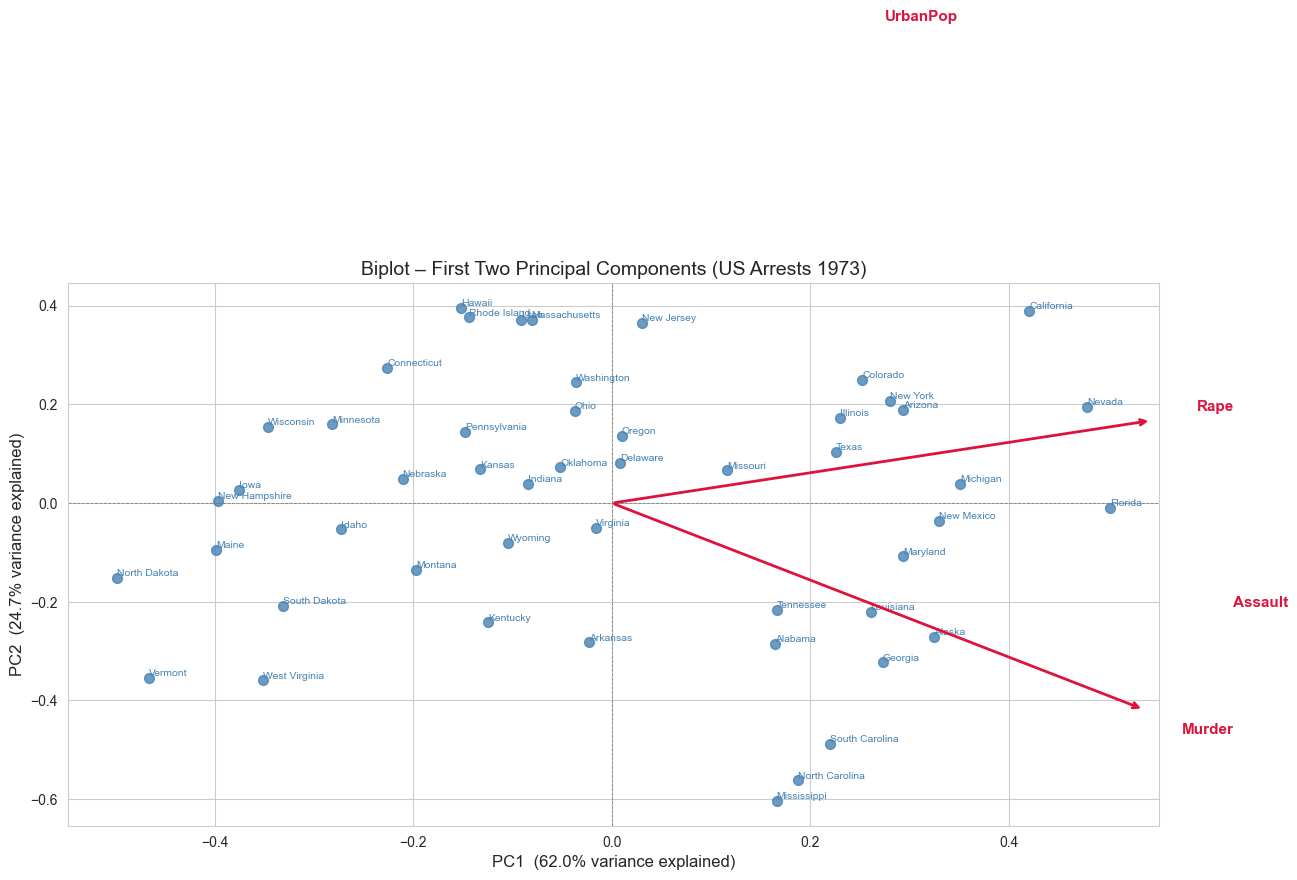

In [6]:
def biplot(scores, components, expl_var, state_labels, feature_labels):
    """Draw a biplot of the first two principal components."""
    fig, ax = plt.subplots(figsize=(13, 10))

    # Scale scores to [-1, 1] for readability
    xs = scores[:, 0]
    ys = scores[:, 1]
    scale_x = 1.0 / (xs.max() - xs.min())
    scale_y = 1.0 / (ys.max() - ys.min())

    # Plot state scores
    ax.scatter(xs * scale_x, ys * scale_y, color='steelblue', s=50, alpha=0.8, zorder=3)
    for i, label in enumerate(state_labels):
        ax.annotate(label, (xs[i] * scale_x, ys[i] * scale_y),
                    fontsize=7.5, ha='left', va='bottom', color='steelblue')

    # Plot loading arrows
    for i, feat in enumerate(feature_labels):
        lx, ly = components[i, 0], components[i, 1]
        ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
        ax.text(lx * 1.12, ly * 1.12, feat, color='crimson',
                fontsize=11, fontweight='bold', ha='center')

    ax.axhline(0, color='grey', linestyle='--', linewidth=0.6)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.6)
    ax.set_xlabel(f'PC1  ({expl_var[0]*100:.1f}% variance explained)', fontsize=12)
    ax.set_ylabel(f'PC2  ({expl_var[1]*100:.1f}% variance explained)', fontsize=12)
    ax.set_title('Biplot – First Two Principal Components (US Arrests 1973)', fontsize=14)
    plt.tight_layout()
    plt.show()

biplot(scores_full, pca_full.components_.T,
       expl_var, df.index.tolist(), df.columns.tolist())

### Biplot Interpretation

**PC1 (horizontal axis, ≈62% variance):**  
All four loading arrows point to the right (positive PC1 direction). Murder, Assault and Rape load strongly in this direction, with UrbanPop loading more moderately. States on the far right (e.g. Florida, Nevada, California) have high crime rates across all three offence types; states on the far left (e.g. North Dakota, Vermont, Iowa) have consistently low crime rates.  
→ **PC1 represents overall violent-crime intensity.**

**PC2 (vertical axis, ≈25% variance):**  
UrbanPop points strongly upward, while Murder and Assault point downward. States at the top (e.g. Hawaii, California, Rhode Island) are highly urbanised with relatively moderate violent crime; states at the bottom (e.g. Mississippi, North Carolina, South Carolina) have high violent crime in predominantly rural settings. Alaska sits in the bottom-right, combining high crime with low urbanisation.  
→ **PC2 contrasts urbanisation against rural violent crime.**

The feature relationships visible in the biplot are consistent with the correlation matrix. Murder and Assault arrows point in almost the same direction (r ≈ 0.80), Rape sits at a smaller angle to both reflecting its moderate correlation with each, and UrbanPop is nearly perpendicular to Murder — consistent with their near-zero correlation (r ≈ 0.07).

## 6. Selecting the Number of Principal Components

To decide how many components to retain, I apply three complementary criteria. The elbow / scree plot suggests retaining PCs up to the point where the curve flattens. The cumulative explained variance criterion requires enough PCs to exceed a commonly used threshold of 80–90%. Finally, the Kaiser criterion retains only PCs whose eigenvalue exceeds 1, meaning each retained component explains more variance than a single standardised feature would on its own.

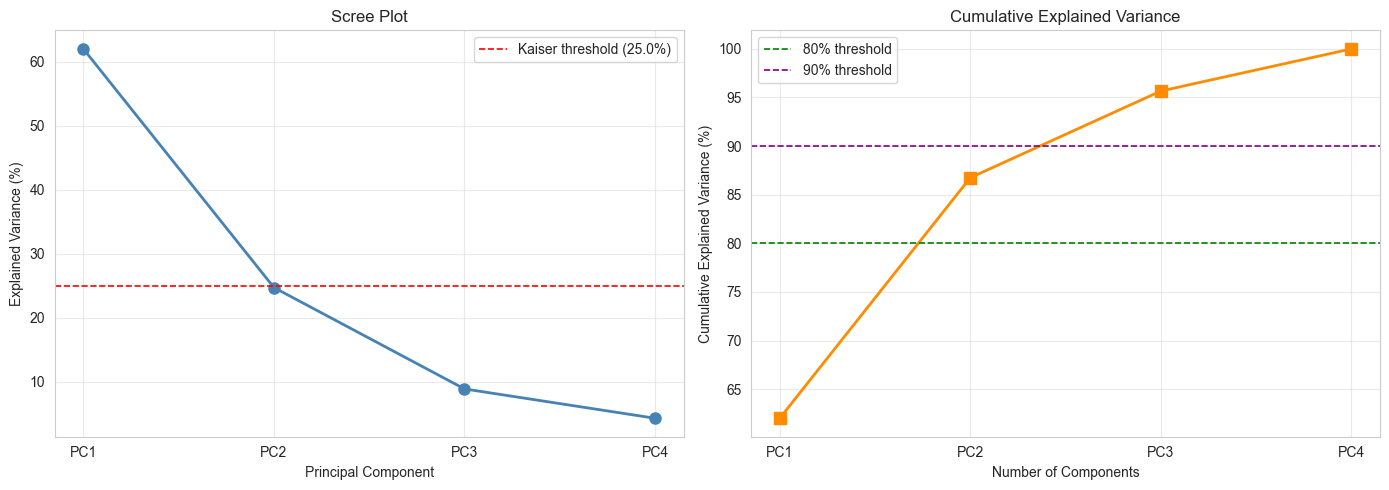

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pc_labels = [f'PC{i+1}' for i in range(len(expl_var))]

# ── Scree plot ───────────────────────────────────────────────────────────────
axes[0].plot(pc_labels, expl_var * 100, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].axhline(100 / len(df.columns), color='red', linestyle='--', linewidth=1.2,
                label=f'Kaiser threshold ({100/len(df.columns):.1f}%)')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].legend()

# ── Cumulative variance ──────────────────────────────────────────────────────
axes[1].plot(pc_labels, cumul_var * 100, 's-', color='darkorange', linewidth=2, markersize=8)
axes[1].axhline(80, color='green',  linestyle='--', linewidth=1.2, label='80% threshold')
axes[1].axhline(90, color='purple', linestyle='--', linewidth=1.2, label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ── Decision ─────────────────────────────────────────────────────────────────
n_components = 2

### Justification for Selecting 2 Principal Components

I retain 2 principal components based on three converging criteria. The scree plot shows a clear elbow after PC2 — the explained variance drops sharply and then flattens, with PC3 and PC4 contributing less than 9% and 5% respectively, offering diminishing returns. On the cumulative variance criterion, PC1 explains ≈62.0% and PC2 explains ≈24.7%, giving a combined total of ≈86.8%, which comfortably exceeds the commonly used 80% threshold. By the Kaiser criterion, both PC1 (eigenvalue = 2.53) and PC2 (eigenvalue = 1.01) have eigenvalues greater than 1, meaning each explains more variance than a single original standardised feature, while PC3 (eigenvalue = 0.36) and PC4 (eigenvalue = 0.18) fall well below this threshold. Retaining 2 PCs also preserves full interpretability as a 2-D projection and provides a clean input space for the clustering analysis that follows.

## 7. Clustering

Two unsupervised clustering techniques are applied to the 2-PC reduced data. K-Means Clustering partitions states into k groups by minimising within-cluster sum of squares, with the optimal *k* chosen via the Elbow method. Hierarchical Clustering (Ward linkage) builds a tree of merges; I cut the dendrogram at a chosen level to obtain flat clusters, where Ward linkage minimises total within-cluster variance at each merge step. Both methods are run on the PCA scores (PC1 and PC2), which is common practice to reduce noise and computational cost while preserving the principal structure of the data.

### 7a. K-Means Clustering

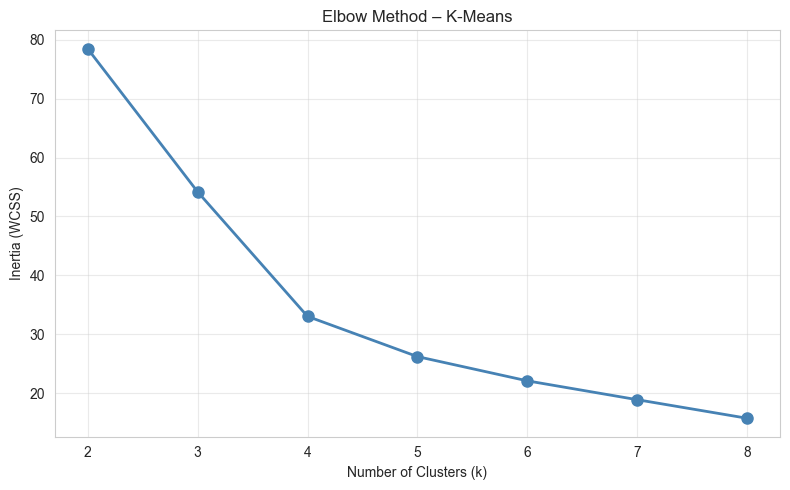

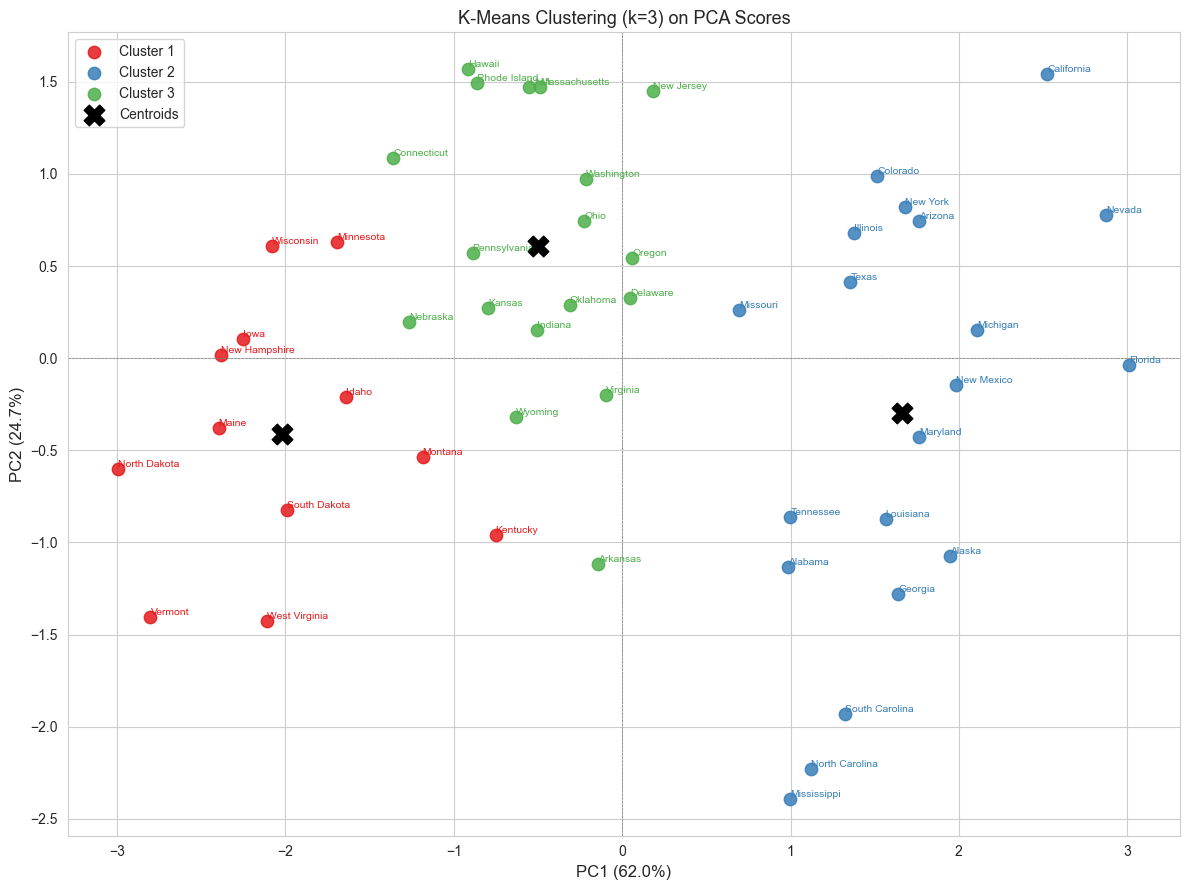

K-Means cluster means (original feature scale):


,Murder,Assault,UrbanPop,Rape
KMeans_Cluster,,,,
1,3.54,76.58,51.25,11.82
2,12.16,255.25,68.40,29.16
3,5.76,139.67,71.89,18.69



States per cluster:
  Cluster 1 (12 states): Idaho, Iowa, Kentucky, Maine, Minnesota, Montana, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin
  Cluster 2 (20 states): Alabama, Alaska, Arizona, California, Colorado, Florida, Georgia, Illinois, Louisiana, Maryland, Michigan, Mississippi, Missouri, Nevada, New Mexico, New York, North Carolina, South Carolina, Tennessee, Texas
  Cluster 3 (18 states): Arkansas, Connecticut, Delaware, Hawaii, Indiana, Kansas, Massachusetts, Nebraska, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming


In [8]:
# ── Project to 2 PCs ─────────────────────────────────────────────────────────
pca_2  = PCA(n_components=n_components)
X_pca  = pca_2.fit_transform(X_scaled)

# ── Elbow method ─────────────────────────────────────────────────────────────
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias.append(km.fit(X_pca).inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method – K-Means')
plt.xticks(K_range)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# ── Fit K-Means with k = 3 ───────────────────────────────────────────────────
K_OPT  = 3
kmeans = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_pca)

CLUSTER_COLOURS = ['#e41a1c', '#377eb8', '#4daf4a']

fig, ax = plt.subplots(figsize=(12, 9))
for c in range(K_OPT):
    mask = km_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=CLUSTER_COLOURS[c], s=80, alpha=0.85, label=f'Cluster {c+1}')
    for i, state in enumerate(df.index):
        if mask[i]:
            ax.annotate(state, (X_pca[i, 0], X_pca[i, 1]),
                        fontsize=7.5, ha='left', va='bottom', color=CLUSTER_COLOURS[c])

ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           marker='X', s=220, color='black', zorder=6, label='Centroids')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.5)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title(f'K-Means Clustering (k={K_OPT}) on PCA Scores', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# ── Cluster summary ───────────────────────────────────────────────────────────
df_km = df.copy()
df_km['KMeans_Cluster'] = km_labels + 1
print("K-Means cluster means (original feature scale):")
display(df_km.groupby('KMeans_Cluster')[df.columns].mean().round(2))

print("\nStates per cluster:")
for c in sorted(df_km['KMeans_Cluster'].unique()):
    states = df_km[df_km['KMeans_Cluster'] == c].index.tolist()
    print(f"  Cluster {c} ({len(states)} states): {', '.join(states)}")

### K-Means Cluster Interpretation

The elbow plot shows a clear bend at k = 3, where the rate of inertia reduction slows considerably — confirming three natural groupings in the data.

| Cluster | States (n) | Avg Murder | Avg Assault | Avg UrbanPop | Profile |
|---|---|---|---|---|---|
| 1 | 12 | 3.5 | 77 | 51 | **Low crime, predominantly rural** — Idaho, Iowa, Vermont, North/South Dakota, etc. |
| 2 | 20 | 12.2 | 255 | 68 | **High crime, mixed urbanisation** — Florida, Nevada, California, Texas, Mississippi, etc. |
| 3 | 18 | 5.8 | 140 | 72 | **Medium crime, more urban** — Ohio, Pennsylvania, Oregon, Virginia, etc. |

States within each cluster share similar socio-economic crime profiles. The high-crime cluster (Cluster 2) is dominated by Southern and Sun Belt states, consistent with historically elevated violent-crime rates in those regions during the 1970s. The low-crime cluster (Cluster 1) is composed largely of rural Midwestern and New England states.

### 7b. Hierarchical Clustering (Ward Linkage)

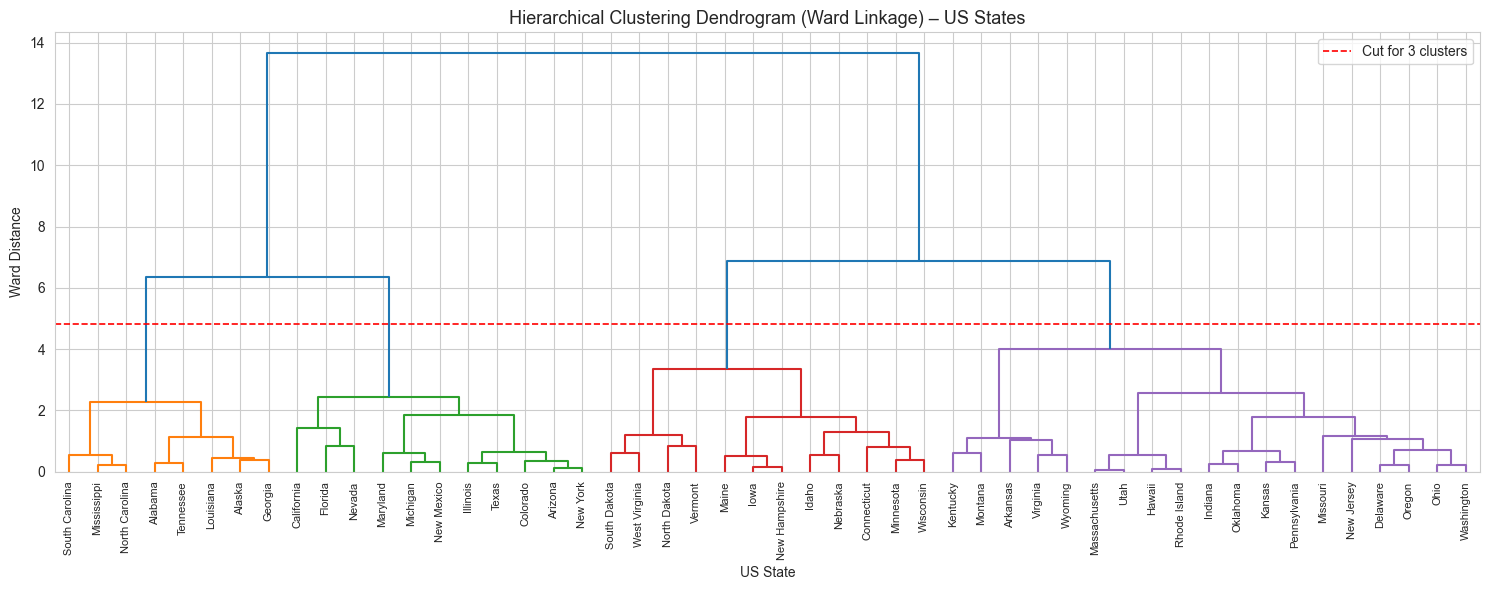

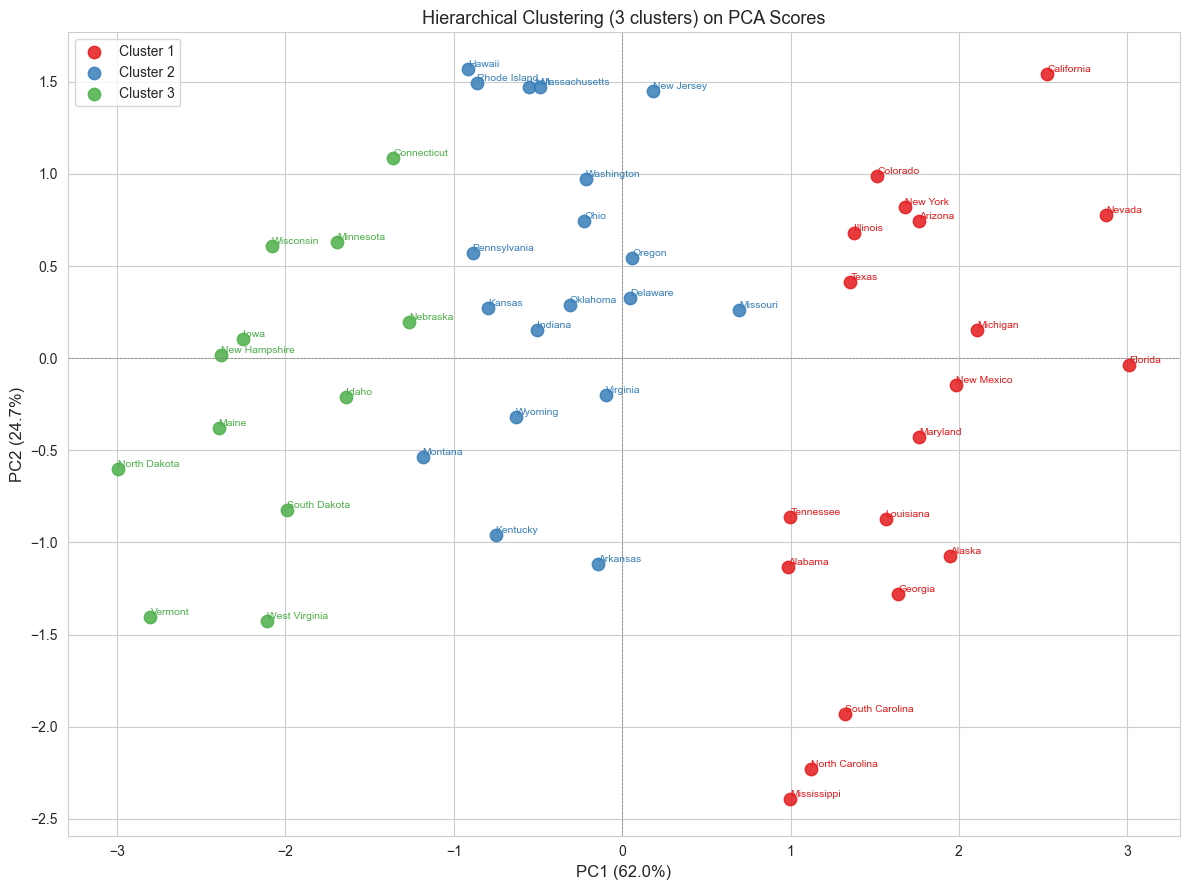

Hierarchical cluster means (original feature scale):


,Murder,Assault,UrbanPop,Rape
Hier_Cluster,,,,
1,12.33,259.32,68.32,29.22
2,6.35,142.00,70.00,19.46
3,2.87,76.08,54.08,11.39



States per cluster:
  Cluster 1 (19 states): Alabama, Alaska, Arizona, California, Colorado, Florida, Georgia, Illinois, Louisiana, Maryland, Michigan, Mississippi, Nevada, New Mexico, New York, North Carolina, South Carolina, Tennessee, Texas
  Cluster 2 (19 states): Arkansas, Delaware, Hawaii, Indiana, Kansas, Kentucky, Massachusetts, Missouri, Montana, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming
  Cluster 3 (12 states): Connecticut, Idaho, Iowa, Maine, Minnesota, Nebraska, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin

Cluster assignment comparison (KMeans vs Hierarchical):


,K-Means,Hierarchical
City,,
Alabama,2,1
Alaska,2,1
Arizona,2,1
Arkansas,3,2
California,2,1
Colorado,2,1
Connecticut,3,3
Delaware,3,2
Florida,2,1


In [9]:
# ── Dendrogram ───────────────────────────────────────────────────────────────
linked = linkage(X_pca, method='ward')

plt.figure(figsize=(15, 6))
dendrogram(linked,
           labels=df.index.tolist(),
           orientation='top',
           leaf_rotation=90,
           color_threshold=linked[-2, 2] * 0.7)   # colour at ~3-cluster cut
plt.axhline(linked[-2, 2] * 0.7, color='red', linestyle='--',
            linewidth=1.2, label='Cut for 3 clusters')
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage) – US States', fontsize=13)
plt.xlabel('US State')
plt.ylabel('Ward Distance')
plt.legend()
plt.tight_layout()
plt.show()

# ── Flat clusters ────────────────────────────────────────────────────────────
N_HIER = 3
hier   = AgglomerativeClustering(n_clusters=N_HIER, linkage='ward')
hier_labels = hier.fit_predict(X_pca)

fig, ax = plt.subplots(figsize=(12, 9))
for c in range(N_HIER):
    mask = hier_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=CLUSTER_COLOURS[c], s=80, alpha=0.85, label=f'Cluster {c+1}')
    for i, state in enumerate(df.index):
        if mask[i]:
            ax.annotate(state, (X_pca[i, 0], X_pca[i, 1]),
                        fontsize=7.5, ha='left', va='bottom', color=CLUSTER_COLOURS[c])

ax.axhline(0, color='grey', linestyle='--', linewidth=0.5)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title(f'Hierarchical Clustering ({N_HIER} clusters) on PCA Scores', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# ── Cluster summaries ─────────────────────────────────────────────────────────
df_hier = df.copy()
df_hier['Hier_Cluster'] = hier_labels + 1
print("Hierarchical cluster means (original feature scale):")
display(df_hier.groupby('Hier_Cluster')[df.columns].mean().round(2))

print("\nStates per cluster:")
for c in sorted(df_hier['Hier_Cluster'].unique()):
    states = df_hier[df_hier['Hier_Cluster'] == c].index.tolist()
    print(f"  Cluster {c} ({len(states)} states): {', '.join(states)}")

# ── Side-by-side comparison ───────────────────────────────────────────────────
print("\nCluster assignment comparison (KMeans vs Hierarchical):")
comparison = pd.DataFrame({
    'K-Means':       df_km['KMeans_Cluster'].values,
    'Hierarchical':  df_hier['Hier_Cluster'].values
}, index=df.index)
display(comparison)

### Hierarchical Cluster Interpretation

The dendrogram reveals a clear two-level hierarchy. The first major split (largest Ward distance) separates the high-crime states from the rest. The second split divides the remainder into medium- and low-crime groups — yielding the same three-profile structure found by K-Means.

| Cluster | States (n) | Avg Murder | Avg Assault | Profile |
|---|---|---|---|---|
| 1 | 19 | 12.3 | 259 | **High crime** — largely the same states as K-Means Cluster 2 |
| 2 | 19 | 6.4 | 142 | **Medium crime** — closely mirrors K-Means Cluster 3, with a few additions |
| 3 | 12 | 2.9 | 76 | **Low crime** — matches K-Means Cluster 1 almost exactly |

**Comparison with K-Means:** The two methods agree on the placement of 44 out of 50 states. The six boundary states that differ (e.g. Kentucky, Montana, Missouri, Delaware) sit near cluster boundaries in PC space, so small algorithmic differences cause them to flip between adjacent clusters. This agreement across two independent methods gives high confidence that the three-cluster solution is a genuine structure in the data, not an artefact of a single algorithm.

## 8. Conclusions

### PCA Findings

PC1 (62.0% variance) represents overall violent-crime intensity, with high positive loadings for Murder (0.54), Assault (0.58), and Rape (0.54), meaning states scoring high on PC1 — such as Florida, Nevada, and California — have elevated crime across all three offence types. PC2 (24.7% variance) contrasts urbanisation (positive loading) against rural violent crime (negative loading); states like Hawaii and California sit near the top of this axis (highly urban, moderate crime), while Mississippi, North Carolina and South Carolina sit at the bottom (low urbanisation, high violent crime). Together, the two retained PCs capture **86.75%** of total variance, which is justifiable under the elbow criterion, the Kaiser criterion (both eigenvalues > 1: 2.53 and 1.01) and the 80% threshold rule.

### Clustering Analysis

| Cluster | K-Means label | Avg Murder | Avg Assault | Avg UrbanPop | Character |
|---|---|---|---|---|---|
| High crime | Cluster 2 (20 states) | 12.2 | 255 | 68 | High violent crime, moderate-to-high urbanisation |
| Medium crime | Cluster 3 (18 states) | 5.8 | 140 | 72 | Moderate crime, more urban |
| Low crime | Cluster 1 (12 states) | 3.5 | 77 | 51 | Low crime, predominantly rural |

Both K-Means and Hierarchical clustering produce very consistent high-level groupings. The same 19–20 high-crime states appear in the top cluster under both methods (e.g. Florida, Nevada, California, Texas, Mississippi, North/South Carolina), and the same 12 low-crime, rural states are consistently grouped together (Vermont, North Dakota, Iowa, Maine, New Hampshire, etc.). Minor disagreements occur only for boundary states such as Kentucky, Montana and Missouri, which lie near cluster edges in PCA space.

**Dendrogram interpretation:** The two highest-level merges in the Ward dendrogram confirm three natural groupings. The first split (distance ≈ 13.5) separates the high-crime block from all others; the second split (distance ≈ 6.8) divides the remaining states into medium- and low-crime groups. This hierarchical structure is entirely consistent with the K-Means solution.

**Overall:** Both algorithms converge on the conclusion that US states in 1973 fell into three broad crime profiles driven primarily by overall violent-crime intensity (PC1). Urbanisation (PC2) adds secondary nuance — high-crime states are not uniformly urban, and some low-crime states (e.g. Connecticut, New Jersey) are highly urbanised, supporting the idea that urbanisation alone does not predict crime rate.